In [1]:
%pip install -U "kagglehub[pandas-datasets]"


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

np.random.seed(42)

file_path = 'training.1600000.processed.noemoticon.csv'

df_raw = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    'kazanova/sentiment140',
    file_path,
    pandas_kwargs={
        'encoding': 'latin-1',
        'header': None,
        'on_bad_lines': 'skip',
    },
)

df_raw.head()

/Users/pete/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/pete/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [3]:
df = df_raw.copy()
df.columns = ['target', 'id', 'date', 'flag', 'user', 'text']
df['target'] = df['target'].replace(4,1)
df = df[['text', 'target']]
df.head()

,text,target
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",0


In [4]:
import re

def clean_tweet(text):
    text = text.lower()  # lowercase

    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+', '', text)     # remove mentions
    text = re.sub(r'#\w+', '', text)     # remove hashtags

    text = re.sub(r'[^a-z\s]', '', text) # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces

    return text

In [5]:
df['clean_text'] = df['text'].apply(clean_tweet)
df[['text', 'clean_text']].head()

,text,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww thats a bummer you shoulda got david carr...
1,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...


In [6]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
print(X_train.shape)
print(X_test.shape)

(1280000,)
(320000,)


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [9]:
X_train_tfidf.shape

(1280000, 5000)

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [11]:
y_pred = model.predict(X_test_tfidf)

In [12]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.79601875

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.78      0.79    160000
           1       0.79      0.81      0.80    160000

    accuracy                           0.80    320000
   macro avg       0.80      0.80      0.80    320000
weighted avg       0.80      0.80      0.80    320000



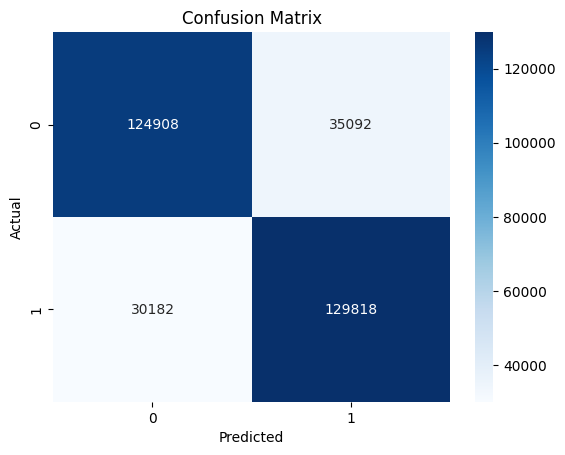

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
import re

EMOTICONS = [
    (r'(?<!\w):-?\)(?!\w)', 'smile'),
    (r'(?<!\w):-?\((?!\w)', 'sad'),
    (r'(?<!\w):d(?!\w)',    'laugh'),
    (r'(?<!\w)<3(?!\w)',    'love'),
    (r'(?<!\w);-?\)(?!\w)', 'wink'),
]

def replace_emoticons(text):
    for pattern, word in EMOTICONS:
        text = re.sub(pattern, f' {word} ', text)
    return text

def clean_tweet_advanced(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' URL ', text)
    text = re.sub(r'@\w+', ' USER ', text)
    text = re.sub(r'#(\w+)', r' \1 ', text)
    text = replace_emoticons(text)          # ← replaces the 6 bare lines
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [15]:
df['clean_text_advanced'] = df['text'].apply(clean_tweet_advanced)
df[['text', 'clean_text', 'clean_text_advanced']].head(10)

,text,clean_text,clean_text_advanced
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww thats a bummer you shoulda got david carr...,a that s a bummer you shoulda got david carr o...
1,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...,is upset that he can t update his facebook by ...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...,no it s not behaving at all i m mad why am i h...
5,@Kwesidei not the whole crew,not the whole crew,not the whole crew
6,Need a hug,need a hug,need a hug
7,@LOLTrish hey long time no see! Yes.. Rains a...,hey long time no see yes rains a bit only a bi...,hey long time no see yes rains a bit only a bi...
8,@Tatiana_K nope they didn't have it,nope they didnt have it,nope they didn t have it
9,@twittera que me muera ?,que me muera,que me muera


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df['clean_text_advanced']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7974125
              precision    recall  f1-score   support

           0       0.81      0.78      0.79    160000
           1       0.79      0.81      0.80    160000

    accuracy                           0.80    320000
   macro avg       0.80      0.80      0.80    320000
weighted avg       0.80      0.80      0.80    320000



## Exploratory Baselines Note

The cells above this point are exploratory baselines used to verify data loading, tweet cleaning, and a simple Logistic Regression workflow. They are useful for incremental development, but they are **not** the final experiment used for the project conclusions.

The final reportable results start in the controlled-comparison section below. That section uses the shared 80/10/10 split, tuned model selection on the validation split, the stricter `high_noise_test` robustness subset, and the export pipeline that writes the final tables and figures to `outputs/`.


## Controlled Comparison Task List

This section completes the remaining proposal work on a fixed stratified split. It does five things:

- Standardizes a shared 80/10/10 train/validation/test split for every model.
- Tunes Logistic Regression, linear SVM, and an MLP neural baseline on the validation split.
- Uses a stable `TF-IDF -> TruncatedSVD -> MLP` pipeline for the neural baseline so the dense model does not train directly on raw sparse TF-IDF.
- Evaluates each model on the full held-out test set and on a stricter high-noise Twitter subset.
- Produces runtime, throughput, confusion matrices, robustness deltas, and error-analysis tables for the final report.


In [17]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TRAIN_FRACTION = 0.80
VALIDATION_FRACTION = 0.10
TEST_FRACTION = 0.10
MAX_FEATURES = 5000
EXPERIMENT_SAMPLE_FRACTION = 1.0  # Lower this for faster notebook iteration if needed.
MODEL_MAX_TRAIN_ROWS = {
    'Logistic Regression': None,
    'Linear SVM': None,
    'MLP Neural Baseline': 100000,
}
NOISE_SUBSET_MIN_COUNT = 2

if 'clean_text_advanced' not in df.columns:
    raise ValueError('Run the advanced preprocessing cells before the controlled comparison section.')

analysis_df = df[['text', 'clean_text_advanced', 'target']].dropna().copy()
analysis_df['text'] = analysis_df['text'].astype(str)
analysis_df['clean_text_advanced'] = analysis_df['clean_text_advanced'].astype(str)

if not 0 < EXPERIMENT_SAMPLE_FRACTION <= 1.0:
    raise ValueError('EXPERIMENT_SAMPLE_FRACTION must be in the interval (0, 1].')

if EXPERIMENT_SAMPLE_FRACTION < 1.0:
    analysis_df = (
        analysis_df
        .groupby('target', group_keys=False)
        .sample(frac=EXPERIMENT_SAMPLE_FRACTION, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )

train_df, holdout_df = train_test_split(
    analysis_df,
    test_size=VALIDATION_FRACTION + TEST_FRACTION,
    random_state=RANDOM_STATE,
    stratify=analysis_df['target']
)

val_df, test_df = train_test_split(
    holdout_df,
    test_size=TEST_FRACTION / (VALIDATION_FRACTION + TEST_FRACTION),
    random_state=RANDOM_STATE,
    stratify=holdout_df['target']
)

train_val_df = pd.concat([train_df, val_df], ignore_index=True)

split_summary = pd.DataFrame([
    {'split': 'train', 'rows': len(train_df), 'positive_rate': train_df['target'].mean()},
    {'split': 'validation', 'rows': len(val_df), 'positive_rate': val_df['target'].mean()},
    {'split': 'test', 'rows': len(test_df), 'positive_rate': test_df['target'].mean()},
])

split_summary


,split,rows,positive_rate
0,train,1280000,0.5
1,validation,160000,0.5
2,test,160000,0.5


In [18]:
from time import perf_counter
from sklearn.decomposition import TruncatedSVD
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import ParameterGrid
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
import warnings

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning, module='sklearn.utils.extmath')

EMOTICON_PATTERN = re.compile(r'(:\)|:-\)|:\(|:-\(|:d|<3|;\)|;\-\))', re.IGNORECASE)
EMOJI_PATTERN = re.compile('[\U0001F300-\U0001FAFF\u2600-\u27BF]+')
REPEATED_CHAR_PATTERN = re.compile(r'(.)\1{2,}')
SLANG_PATTERN = re.compile(r'\b(lol|omg|wtf|idk|smh|tbh|imo|btw|lmao|rofl|ikr|u|ur|ya|tho|gonna|wanna)\b', re.IGNORECASE)
NEGATION_PATTERN = re.compile(r"\b(no|not|never|can't|cannot|don't|didn't|isn't|wasn't|won't|shouldn't|couldn't)\b", re.IGNORECASE)
SARCASTIC_PATTERN = re.compile(r'\b(yeah right|as if|sure jan)\b', re.IGNORECASE)

NOISE_COLUMNS = [
    'has_url',
    'has_mention',
    'has_hashtag',
    'has_repeated_chars',
    'has_emoticon',
    'has_emoji',
    'has_slang',
]

STRONG_NOISE_COLUMNS = [
    'has_url',
    'has_hashtag',
    'has_repeated_chars',
    'has_emoticon',
    'has_emoji',
    'has_slang',
]

ERROR_TAG_COLUMNS = [
    'has_negation',
    'has_sarcasm_marker',
    'has_all_caps',
    'has_excess_punctuation',
]

def add_noise_and_error_flags(frame):
    tagged = frame.copy()
    tagged['has_url'] = tagged['text'].str.contains(r'http\S+|www\.\S+', regex=True, na=False)
    tagged['has_mention'] = tagged['text'].str.contains(r'@\w+', regex=True, na=False)
    tagged['has_hashtag'] = tagged['text'].str.contains(r'#\w+', regex=True, na=False)
    tagged['has_repeated_chars'] = tagged['text'].apply(lambda value: bool(REPEATED_CHAR_PATTERN.search(str(value))))
    tagged['has_emoticon'] = tagged['text'].apply(lambda value: bool(EMOTICON_PATTERN.search(str(value))))
    tagged['has_emoji'] = tagged['text'].apply(lambda value: bool(EMOJI_PATTERN.search(str(value))))
    tagged['has_slang'] = tagged['text'].apply(lambda value: bool(SLANG_PATTERN.search(str(value))))
    tagged['noise_count'] = tagged[NOISE_COLUMNS].sum(axis=1)
    tagged['strong_noise_count'] = tagged[STRONG_NOISE_COLUMNS].sum(axis=1)
    tagged['is_noisy'] = tagged['noise_count'] > 0
    tagged['is_high_noise'] = (tagged['noise_count'] >= NOISE_SUBSET_MIN_COUNT) & (tagged['strong_noise_count'] >= 1)
    tagged['has_negation'] = tagged['text'].apply(lambda value: bool(NEGATION_PATTERN.search(str(value))))
    tagged['has_sarcasm_marker'] = tagged['text'].apply(lambda value: bool(SARCASTIC_PATTERN.search(str(value))))
    tagged['has_all_caps'] = tagged['text'].str.contains(r'\b[A-Z]{3,}\b', regex=True, na=False)
    tagged['has_excess_punctuation'] = tagged['text'].str.contains(r'[!?]{2,}', regex=True, na=False)
    return tagged

def build_vectorizer(vectorizer_config):
    return TfidfVectorizer(
        max_features=vectorizer_config.get('max_features', MAX_FEATURES),
        min_df=vectorizer_config['min_df'],
        ngram_range=vectorizer_config['ngram_range'],
        sublinear_tf=True,
    )

def build_feature_bundle(vectorizer_config):
    bundle = {
        'vectorizer': build_vectorizer(vectorizer_config),
        'svd': None,
    }
    if vectorizer_config.get('svd_n_components') is not None:
        bundle['svd'] = TruncatedSVD(
            n_components=vectorizer_config['svd_n_components'],
            random_state=RANDOM_STATE,
        )
    return bundle

def fit_transform_features(feature_bundle, texts):
    features = feature_bundle['vectorizer'].fit_transform(texts)
    if feature_bundle['svd'] is not None:
        return feature_bundle['svd'].fit_transform(features)
    return features

def transform_features(feature_bundle, texts):
    features = feature_bundle['vectorizer'].transform(texts)
    if feature_bundle['svd'] is not None:
        return feature_bundle['svd'].transform(features)
    return features

def sample_training_frame(frame, model_name):
    max_rows = MODEL_MAX_TRAIN_ROWS.get(model_name)
    if max_rows is None or len(frame) <= max_rows:
        return frame.reset_index(drop=True)

    sampled_frame, _ = train_test_split(
        frame,
        train_size=max_rows,
        random_state=RANDOM_STATE,
        stratify=frame['target'],
    )
    return sampled_frame.reset_index(drop=True)

def build_model(model_name, model_config):
    if model_name == 'Logistic Regression':
        return LogisticRegression(
            C=model_config['C'],
            max_iter=1000,
            solver='liblinear',
            random_state=RANDOM_STATE,
        )
    if model_name == 'Linear SVM':
        return LinearSVC(
            C=model_config['C'],
            dual=False,
            max_iter=5000,
            random_state=RANDOM_STATE,
        )
    if model_name == 'MLP Neural Baseline':
        return MLPClassifier(
            hidden_layer_sizes=model_config['hidden_layer_sizes'],
            alpha=model_config['alpha'],
            learning_rate_init=model_config['learning_rate_init'],
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            max_iter=30,
            batch_size='auto',
            random_state=RANDOM_STATE,
        )
    raise ValueError(f'Unsupported model: {model_name}')

def get_scores(model, features):
    if hasattr(model, 'decision_function'):
        return model.decision_function(features)
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(features)[:, 1]
    raise ValueError('Model must expose decision_function or predict_proba for ROC-AUC.')

def summarize_metrics(y_true, y_pred, y_score):
    roc_auc = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) > 1 else float('nan')
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc,
    }

def parameter_count(model):
    if hasattr(model, 'coef_'):
        return int(model.coef_.size + model.intercept_.size)
    if hasattr(model, 'coefs_'):
        return int(sum(arr.size for arr in model.coefs_) + sum(arr.size for arr in model.intercepts_))
    return None

test_df = add_noise_and_error_flags(test_df)
any_noise_test_df = test_df[test_df['is_noisy']].copy()
noisy_test_df = test_df[test_df['is_high_noise']].copy()

subset_summary = pd.DataFrame([
    {
        'subset': 'full_test',
        'rows': len(test_df),
        'share_of_test': 1.0,
        'definition': 'All held-out test tweets',
    },
    {
        'subset': 'any_noise_test',
        'rows': len(any_noise_test_df),
        'share_of_test': len(any_noise_test_df) / len(test_df),
        'definition': 'At least one Twitter-specific noise marker',
    },
    {
        'subset': 'high_noise_test',
        'rows': len(noisy_test_df),
        'share_of_test': len(noisy_test_df) / len(test_df),
        'definition': 'At least two noise markers and at least one strong noise marker',
    },
])

noise_summary = (
    test_df[NOISE_COLUMNS + ['noise_count', 'strong_noise_count', 'is_noisy', 'is_high_noise']]
    .mean(numeric_only=True)
    .sort_values(ascending=False)
    .rename('share_of_test_set')
)

print(f'High-noise subset size: {len(noisy_test_df):,} / {len(test_df):,}')
display(subset_summary)
noise_summary


High-noise subset size: 34,445 / 160,000


,subset,rows,share_of_test,definition
0,full_test,160000,1.000000,All held-out test tweets
1,any_noise_test,106942,0.668388,At least one Twitter-specific noise marker
2,high_noise_test,34445,0.215281,At least two noise markers and at least one st...


noise_count           0.923300
is_noisy              0.668388
strong_noise_count    0.462925
has_mention           0.460375
has_repeated_chars    0.276206
is_high_noise         0.215281
has_slang             0.110294
has_url               0.048287
has_hashtag           0.022669
has_emoticon          0.005469
has_emoji             0.000000
Name: share_of_test_set, dtype: float64

In [19]:
vectorizer_grid = {
    'Logistic Regression': [
        {'ngram_range': (1, 1), 'min_df': 5, 'max_features': MAX_FEATURES},
        {'ngram_range': (1, 2), 'min_df': 5, 'max_features': MAX_FEATURES},
    ],
    'Linear SVM': [
        {'ngram_range': (1, 1), 'min_df': 5, 'max_features': MAX_FEATURES},
        {'ngram_range': (1, 2), 'min_df': 5, 'max_features': MAX_FEATURES},
    ],
    'MLP Neural Baseline': [
        {'ngram_range': (1, 1), 'min_df': 5, 'max_features': 5000, 'svd_n_components': 300},
    ],
}

model_grids = {
    'Logistic Regression': {
        'C': [0.5, 1.0, 2.0],
    },
    'Linear SVM': {
        'C': [0.5, 1.0, 2.0],
    },
    'MLP Neural Baseline': {
        'hidden_layer_sizes': [(64,), (128,)],
        'alpha': [1e-2, 5e-2],
        'learning_rate_init': [1e-4],
    },
}

validation_rows = []
best_configs = {}

for model_name, model_grid in model_grids.items():
    model_best_row = None
    model_train_df = sample_training_frame(train_df, model_name)

    for vectorizer_config in vectorizer_grid[model_name]:
        feature_bundle = build_feature_bundle(vectorizer_config)
        X_train = fit_transform_features(feature_bundle, model_train_df['clean_text_advanced'])
        X_val = transform_features(feature_bundle, val_df['clean_text_advanced'])

        for model_config in ParameterGrid(model_grid):
            model = build_model(model_name, model_config)

            train_start = perf_counter()
            model.fit(X_train, model_train_df['target'])
            train_time = perf_counter() - train_start

            score_start = perf_counter()
            val_pred = model.predict(X_val)
            val_score = get_scores(model, X_val)
            inference_time = perf_counter() - score_start

            row = {
                'model': model_name,
                'ngram_range': vectorizer_config['ngram_range'],
                'min_df': vectorizer_config['min_df'],
                'max_features': vectorizer_config.get('max_features', MAX_FEATURES),
                'svd_n_components': vectorizer_config.get('svd_n_components'),
                'training_rows': len(model_train_df),
                'train_time_sec': train_time,
                'validation_inference_sec': inference_time,
                'params': parameter_count(model),
            }
            row.update(model_config)
            row.update(summarize_metrics(val_df['target'], val_pred, val_score))
            validation_rows.append(row)

            if model_best_row is None or row['f1'] > model_best_row['f1']:
                model_best_row = row.copy()

    best_configs[model_name] = model_best_row

validation_results = pd.DataFrame(validation_rows).sort_values(['model', 'f1', 'roc_auc'], ascending=[True, False, False])
best_config_summary = pd.DataFrame(best_configs.values()).sort_values('f1', ascending=False).reset_index(drop=True)

best_config_summary


,model,ngram_range,min_df,max_features,svd_n_components,training_rows,train_time_sec,validation_inference_sec,params,C,accuracy,precision,recall,f1,roc_auc,alpha,hidden_layer_sizes,learning_rate_init
0,Linear SVM,"(1, 2)",5,5000,NaN,1280000,7.935718,0.006627,5001,0.5,0.796713,0.787338,0.813025,0.799975,0.877388,NaN,NaN,NaN
1,Logistic Regression,"(1, 2)",5,5000,NaN,1280000,4.790096,0.006920,5001,0.5,0.797206,0.789692,0.810175,0.799803,0.877616,NaN,NaN,NaN
2,MLP Neural Baseline,"(1, 1)",5,5000,300.0,100000,3.283887,0.167153,38657,NaN,0.741213,0.733287,0.758200,0.745535,0.820043,0.01,"(128,)",0.0001


In [20]:
final_models = {}
comparison_rows = []
prediction_store = {}
score_store = {}
report_store = {}
confusion_store = {}

for model_name, best_config in best_configs.items():
    model_train_val_df = sample_training_frame(train_val_df, model_name)
    vectorizer_config = {
        'ngram_range': tuple(best_config['ngram_range']),
        'min_df': int(best_config['min_df']),
        'max_features': int(best_config['max_features']),
        'svd_n_components': None if pd.isna(best_config.get('svd_n_components')) else int(best_config['svd_n_components']),
    }
    model_config = {
        key: best_config[key]
        for key in best_config.keys()
        if key in {'C', 'hidden_layer_sizes', 'alpha', 'learning_rate_init'} and not pd.isna(best_config[key])
    }

    feature_bundle = build_feature_bundle(vectorizer_config)
    X_train_val = fit_transform_features(feature_bundle, model_train_val_df['clean_text_advanced'])
    model = build_model(model_name, model_config)

    train_start = perf_counter()
    model.fit(X_train_val, model_train_val_df['target'])
    train_time = perf_counter() - train_start

    final_models[model_name] = {
        'vectorizer': feature_bundle['vectorizer'],
        'svd': feature_bundle['svd'],
        'model': model,
        'config': {**vectorizer_config, **model_config},
        'parameter_count': parameter_count(model),
    }

    for split_name, frame in [('full_test', test_df), ('high_noise_test', noisy_test_df)]:
        if frame.empty:
            continue

        X_eval = transform_features(feature_bundle, frame['clean_text_advanced'])

        predict_start = perf_counter()
        y_pred = model.predict(X_eval)
        prediction_time = perf_counter() - predict_start

        score_start = perf_counter()
        y_score = get_scores(model, X_eval)
        scoring_time = perf_counter() - score_start

        metrics = summarize_metrics(frame['target'], y_pred, y_score)
        metrics.update({
            'model': model_name,
            'split': split_name,
            'rows': len(frame),
            'training_rows': len(model_train_val_df),
            'train_time_sec': train_time,
            'prediction_time_sec': prediction_time,
            'scoring_time_sec': scoring_time,
            'tweets_per_second': len(frame) / prediction_time if prediction_time > 0 else float('inf'),
            'parameter_count': final_models[model_name]['parameter_count'],
        })
        comparison_rows.append(metrics)

        if split_name == 'full_test':
            prediction_store[model_name] = y_pred
            score_store[model_name] = y_score
            report_store[model_name] = classification_report(frame['target'], y_pred, digits=4)
            confusion_store[model_name] = confusion_matrix(frame['target'], y_pred)

comparison_results = pd.DataFrame(comparison_rows).sort_values(['split', 'f1', 'roc_auc'], ascending=[True, False, False]).reset_index(drop=True)

full_results = comparison_results[comparison_results['split'] == 'full_test'].set_index('model')
high_noise_results = comparison_results[comparison_results['split'] == 'high_noise_test'].set_index('model')
robustness_delta = (
    high_noise_results[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
    .subtract(full_results[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']], fill_value=np.nan)
    .rename(columns=lambda column: f'{column}_delta_high_noise_minus_full')
    .reset_index()
)

display(comparison_results[['model', 'split', 'rows', 'training_rows', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'train_time_sec', 'prediction_time_sec', 'tweets_per_second', 'parameter_count']])
robustness_delta


,model,split,rows,training_rows,accuracy,precision,recall,f1,roc_auc,train_time_sec,prediction_time_sec,tweets_per_second,parameter_count
0,Linear SVM,full_test,160000,1440000,0.797488,0.787407,0.815025,0.800978,0.878336,8.850275,0.002851,5.613050e+07,5001
1,Logistic Regression,full_test,160000,1440000,0.798019,0.790025,0.811800,0.800764,0.878590,7.200041,0.002798,5.718031e+07,5001
2,MLP Neural Baseline,full_test,160000,100000,0.743625,0.737266,0.757025,0.747015,0.822701,5.153760,0.092775,1.724607e+06,38657
3,Linear SVM,high_noise_test,34445,1440000,0.778081,0.794424,0.825179,0.809510,0.855501,8.850275,0.000668,5.154184e+07,5001
4,Logistic Regression,high_noise_test,34445,1440000,0.777762,0.795557,0.822436,0.808773,0.855772,7.200041,0.001781,1.933574e+07,5001
5,MLP Neural Baseline,high_noise_test,34445,100000,0.732153,0.758901,0.778641,0.768644,0.802110,5.153760,0.021384,1.610781e+06,38657


,model,accuracy_delta_high_noise_minus_full,precision_delta_high_noise_minus_full,recall_delta_high_noise_minus_full,f1_delta_high_noise_minus_full,roc_auc_delta_high_noise_minus_full
0,Linear SVM,-0.019407,0.007017,0.010154,0.008532,-0.022835
1,Logistic Regression,-0.020257,0.005532,0.010636,0.008009,-0.022817
2,MLP Neural Baseline,-0.011472,0.021634,0.021616,0.021629,-0.020591


Logistic Regression
              precision    recall  f1-score   support

           0     0.8065    0.7842    0.7952     80000
           1     0.7900    0.8118    0.8008     80000

    accuracy                         0.7980    160000
   macro avg     0.7982    0.7980    0.7980    160000
weighted avg     0.7982    0.7980    0.7980    160000

--------------------------------------------------------------------------------
Linear SVM
              precision    recall  f1-score   support

           0     0.8083    0.7800    0.7939     80000
           1     0.7874    0.8150    0.8010     80000

    accuracy                         0.7975    160000
   macro avg     0.7979    0.7975    0.7974    160000
weighted avg     0.7979    0.7975    0.7974    160000

--------------------------------------------------------------------------------
MLP Neural Baseline
              precision    recall  f1-score   support

           0     0.7503    0.7302    0.7401     80000
           1     0.7373 

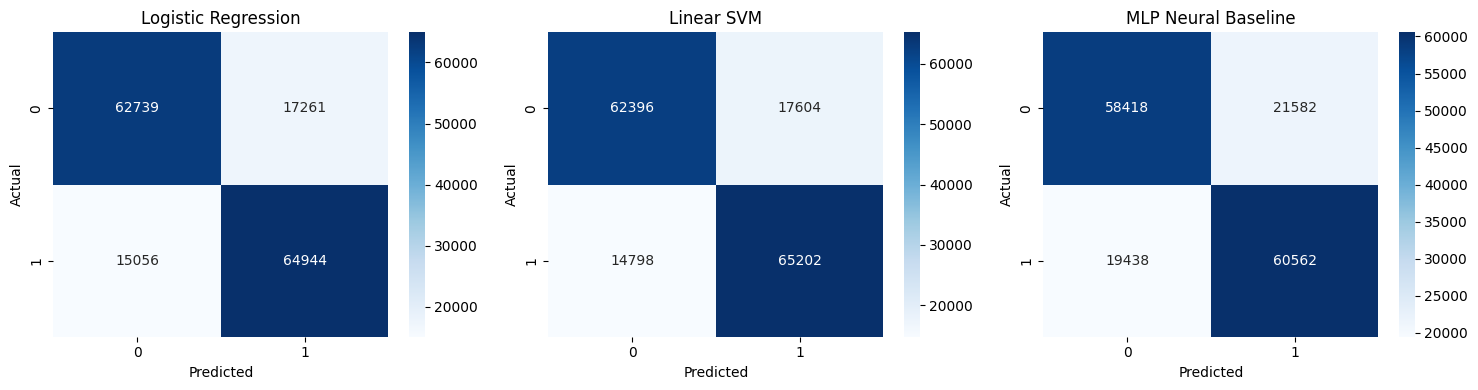

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

for model_name, report in report_store.items():
    print(model_name)
    print(report)
    print('-' * 80)

fig, axes = plt.subplots(1, len(confusion_store), figsize=(5 * len(confusion_store), 4))
if len(confusion_store) == 1:
    axes = [axes]

for ax, (model_name, cm) in zip(axes, confusion_store.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


In [22]:
def build_error_table(frame, y_pred, y_score, model_name):
    error_frame = frame.copy().reset_index(drop=True)
    error_frame['prediction'] = y_pred
    error_frame['score'] = y_score
    error_frame['model'] = model_name
    error_frame['error_type'] = np.where(
        (error_frame['target'] == 0) & (error_frame['prediction'] == 1),
        'false_positive',
        np.where(
            (error_frame['target'] == 1) & (error_frame['prediction'] == 0),
            'false_negative',
            'correct'
        )
    )
    return error_frame[error_frame['error_type'] != 'correct'].copy()

error_frames = []
for model_name, y_pred in prediction_store.items():
    error_frames.append(build_error_table(test_df, y_pred, score_store[model_name], model_name))

all_errors = pd.concat(error_frames, ignore_index=True) if error_frames else pd.DataFrame()

if not all_errors.empty:
    error_category_summary = (
        all_errors
        .groupby(['model', 'error_type'])[NOISE_COLUMNS + ERROR_TAG_COLUMNS]
        .mean()
        .round(3)
    )

    representative_errors = (
        all_errors
        .assign(confidence_margin=lambda frame: np.abs(frame['score']))
        .sort_values(['model', 'confidence_margin'], ascending=[True, False])
        .groupby(['model', 'error_type'])
        .head(5)
        [['model', 'error_type', 'text', 'target', 'prediction', 'score'] + NOISE_COLUMNS + ERROR_TAG_COLUMNS]
        .reset_index(drop=True)
    )

    display(error_category_summary)
    display(representative_errors)
else:
    print('No misclassifications were captured. Re-run the evaluation cells first.')


has_url  has_mention  has_hashtag  \
model               error_type                                          
Linear SVM          false_negative    0.044        0.488        0.021   
                    false_positive    0.040        0.486        0.023   
Logistic Regression false_negative    0.045        0.487        0.021   
                    false_positive    0.039        0.490        0.023   
MLP Neural Baseline false_negative    0.052        0.478        0.022   
                    false_positive    0.040        0.465        0.023   

                                    has_repeated_chars  has_emoticon  \
model               error_type                                         
Linear SVM          false_negative               0.284         0.005   
                    false_positive               0.296         0.007   
Logistic Regression false_negative               0.283         0.006   
                    false_positive               0.297         0.007   
MLP Neural Baseline false_negative               0.283         0.005   
                    false_positive               0.289         0.006   

                                    has_emoji  has_slang  has_negation  \
model               error_type                                           
Linear SVM          false_negative        0.0      0.129         0.291   
                    false_positive        0.0      0.121         0.170   
Logistic Regression false_negative        0.0      0.129         0.290   
                    false_positive        0.0      0.122         0.171   
MLP Neural Baseline false_negative        0.0      0.115         0.276   
                    false_positive        0.0      0.119         0.154   

                                    has_sarcasm_marker  has_all_caps  \
model               error_type                                         
Linear SVM          false_negative               0.000         0.123   
                    false_positive               0.001         0.116   
Logistic Regression false_negative               0.000         0.123   
                    false_positive               0.001         0.116   
MLP Neural Baseline false_negative               0.000         0.120   
                    false_positive               0.001         0.117   

                                    has_excess_punctuation  
model               error_type                              
Linear SVM          false_negative                   0.094  
                    false_positive                   0.089  
Logistic Regression false_negative                   0.093  
                    false_positive                   0.090  
MLP Neural Baseline false_negative                   0.095  
                    false_positive                   0.088

,model,error_type,text,target,prediction,score,has_url,has_mention,has_hashtag,has_repeated_chars,has_emoticon,has_emoji,has_slang,has_negation,has_sarcasm_marker,has_all_caps,has_excess_punctuation
0,Linear SVM,false_negative,@alex17croatia :o no sad faces! only smiles,1,0,-3.101596,False,True,False,False,False,False,False,True,False,False,False
1,Linear SVM,false_negative,@druey unfortunately i cannot. sorry. #badoptus,1,0,-2.555508,False,True,True,False,False,False,False,True,False,False,False
2,Linear SVM,false_negative,Internet is down in my house-- so sad! At leas...,1,0,-2.319994,False,False,False,False,False,False,False,False,False,False,False
3,Linear SVM,false_negative,Got the WORST migraine at skool 2day.A bit dra...,1,0,-2.234986,False,False,False,False,False,False,False,True,False,True,False
4,Linear SVM,false_negative,@kbspectacular Thai pillows! Miss u! http://t...,1,0,-2.193309,True,True,False,False,False,False,True,False,False,False,False
5,Linear SVM,false_positive,@thisisjulze goood luccck love *L(,0,1,2.035315,False,True,False,True,False,False,False,False,False,False,False
6,Linear SVM,false_positive,I am finally home from my night out. It was fu...,0,1,1.989512,False,False,False,True,False,False,False,False,False,False,False
7,Linear SVM,false_positive,@MsKitty0303 your welcome,0,1,1.925372,False,True,False,False,False,False,False,False,False,False,False
8,Linear SVM,false_positive,"@WhiteHowler how dare you insult your loving, ...",0,1,1.748903,False,True,False,False,False,False,False,False,False,False,False
9,Linear SVM,false_positive,@JonasAustralia That quote is amazing. I almos...,0,1,1.694433,False,True,False,False,False,False,False,False,False,False,False


In [23]:
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

output_dir = Path('outputs')
output_dir.mkdir(exist_ok=True)

for model_name, bundle in final_models.items():
    artifact_prefix = model_name.lower().replace(' ', '_')
    joblib.dump(bundle['vectorizer'], output_dir / f'{artifact_prefix}_vectorizer.pkl')
    joblib.dump(bundle['model'], output_dir / f'{artifact_prefix}_model.pkl')
    if bundle['svd'] is not None:
        joblib.dump(bundle['svd'], output_dir / f'{artifact_prefix}_svd.pkl')

split_summary.to_csv(output_dir / 'split_summary.csv', index=False)
subset_summary.to_csv(output_dir / 'subset_summary.csv', index=False)
best_config_summary.to_csv(output_dir / 'best_config_summary.csv', index=False)
validation_results.to_csv(output_dir / 'validation_results.csv', index=False)
comparison_results.to_csv(output_dir / 'comparison_results.csv', index=False)
robustness_delta.to_csv(output_dir / 'robustness_delta.csv', index=False)
noise_summary.rename_axis('feature').reset_index().to_csv(output_dir / 'noise_summary.csv', index=False)

if 'error_category_summary' in globals():
    error_category_summary.reset_index().to_csv(output_dir / 'error_category_summary.csv', index=False)
if 'representative_errors' in globals():
    representative_errors.to_csv(output_dir / 'representative_errors.csv', index=False)

fig, axes = plt.subplots(1, len(confusion_store), figsize=(5 * len(confusion_store), 4))
if len(confusion_store) == 1:
    axes = [axes]

for ax, (model_name, cm) in zip(axes, confusion_store.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
fig.savefig(output_dir / 'confusion_matrices.png', dpi=200, bbox_inches='tight')
plt.close(fig)

delta_plot = robustness_delta.copy().set_index('model')['f1_delta_high_noise_minus_full'].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
delta_plot.plot(kind='bar', ax=ax, color=['#1f77b4', '#2ca02c', '#ff7f0e'])
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('F1 Delta')
ax.set_title('High-Noise F1 Change Relative to Full Test')
plt.tight_layout()
fig.savefig(output_dir / 'robustness_delta_f1.png', dpi=200, bbox_inches='tight')
plt.close(fig)

print('Saved tuned model artifacts, figures, and report tables to the outputs/ directory.')


Saved tuned model artifacts, figures, and report tables to the outputs/ directory.


## Final Evaluation Writeup

The final comparison used a fixed stratified 80/10/10 train/validation/test split with 1,280,000 training tweets, 160,000 validation tweets, and 160,000 held-out test tweets. Logistic Regression and linear SVM were tuned on the full training split with TF-IDF features, while the MLP neural baseline was tuned on a capped stratified sample of 100,000 tweets for computational feasibility.

The neural baseline now uses a `TF-IDF -> TruncatedSVD -> MLP` pipeline instead of feeding raw sparse TF-IDF directly into the dense network. In the final run, the selected neural configuration used unigram TF-IDF with 5,000 features, `TruncatedSVD` with 300 components, a hidden layer of 128 units, `alpha = 0.01`, and `learning_rate_init = 0.0001`. This made the neural section numerically stable, but the neural baseline still underperformed the classical baselines.

On the full test split, the strongest model by F1-score was the linear SVM with `F1 = 0.800978`, followed very closely by Logistic Regression with `F1 = 0.800764`. Logistic Regression produced the best ROC-AUC at `0.878590`, while linear SVM reached `0.878336`. The stabilized MLP neural baseline trailed both classical models with `F1 = 0.747015` and `ROC-AUC = 0.822701`. Primary metrics are accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices. Accuracy summarizes overall correctness, while precision and recall show how each model trades off false positives and false negatives. F1-score is the main tuning metric because it balances precision and recall on the binary sentiment task.

To test robustness, each model is evaluated twice: once on the full test split and once on a stricter `high_noise_test` subset of 34,445 tweets containing at least two noise markers and at least one strong Twitter-specific artifact such as a hashtag, repeated characters, slang term, emoticon, or URL. On this harder subset, accuracy and ROC-AUC fell for every model, but F1 increased slightly because recall improved more than precision declined. The `robustness_delta` table and exported figures summarize that mixed effect.


## Error Analysis Method and Success Criteria

Error analysis focuses on false positives and false negatives from the held-out test set. After inference, each mistake is tagged with interpretable linguistic markers such as negation, sarcasm cues, all-caps emphasis, repeated punctuation, hashtags, emojis, and slang. The grouped error table identifies which failure modes dominate for each model family, and the representative-error table gives concrete tweets to inspect in the final report.

The final report should interpret the robustness results carefully. A model can show a higher F1-score on the high-noise subset while still losing accuracy or ROC-AUC, so the notebook exports a dedicated `robustness_delta` table rather than relying on a single metric. In the final run, all three models lost about `0.02` ROC-AUC on `high_noise_test`, while F1 increased by `0.008532` for linear SVM, `0.008009` for Logistic Regression, and `0.021629` for the MLP.

The project meets the proposal's minimum success criteria when the notebook contains: (1) tuned TF-IDF + Logistic Regression and TF-IDF + linear SVM baselines, (2) at least one tuned neural model, implemented here as an MLP over a reduced dense representation with early stopping, (3) evaluation on the same fixed split using accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices, and (4) a comparison between the full test set and a high-noise Twitter-specific subset. The final results show that the classical TF-IDF baselines remained stronger than the neural baseline even after the MLP pipeline was stabilized.


## Resources and Contributions

The project uses the Sentiment140 dataset loaded through `kagglehub`, advanced tweet normalization implemented in the notebook, and scikit-learn models for both classical and neural baselines. The final export step writes reusable artifacts and report tables to `outputs/`, including split summaries, subset definitions, validation-search results, final comparison metrics, robustness deltas, noise summaries, representative error tables, and saved confusion-matrix and robustness figures.

Contribution status after the notebook is run:

- Member 1 work is represented by data loading, preprocessing, and the Logistic Regression baseline.
- Member 2 work is represented by the shared split, tuned linear SVM, stricter robustness subset, expanded metrics, confusion matrices, and evaluation/error-analysis writeup.
- Shared work is represented by the MLP neural baseline, runtime and throughput reporting, artifact export, and the final integrated comparison across model families.

Final conclusion: the strongest models in this project were the classical TF-IDF baselines, not the neural baseline. Linear SVM achieved the best full-test F1-score, Logistic Regression achieved the best full-test ROC-AUC, and both clearly outperformed the stabilized MLP while also being faster. The stricter high-noise evaluation changed the metric balance, but it did not change the overall model ranking.
